# Second Serve — Food Decay Model

Trains 3 regression models (human / animal / compost remaining hours)
and 1 stage classifier (human / animal / compost / waste).

Run this notebook FIRST before train_knn_model.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

print('Libraries loaded')

Libraries loaded


## 1. Load Datasets

In [2]:
# Primary reference dataset — has human/animal/compost timelines
ref_df = pd.read_csv('food_dataset.csv')
print('Reference dataset:', ref_df.shape)
print(ref_df.columns.tolist())
ref_df.head()

Reference dataset: (61, 9)
['food_name', 'category', 'food_type', 'human_safe_hours', 'animal_safe_hours', 'compost_hours', 'storage_temp', 'risk_level', 'notes']


,food_name,category,food_type,human_safe_hours,animal_safe_hours,compost_hours,storage_temp,risk_level,notes
0,Rice (cooked),Mains,veg,6,12,24,room_temp,medium,Spoils faster in heat
1,Dal (cooked),Mains,veg,6,12,24,room_temp,medium,Store covered
2,Chicken Curry,Mains,non-veg,4,8,18,room_temp,high,High protein spoilage risk
3,Mutton Curry,Mains,non-veg,4,8,18,room_temp,high,High protein spoilage risk
4,Fish Curry,Mains,non-veg,3,6,16,room_temp,high,Spoils fastest of all meats


In [3]:
# Kaggle food spoilage dataset (optional enrichment)
# Download from: https://www.kaggle.com/datasets/devankitsarkar/food-spoilage-data
# Place in ml_pipeline/data/food_spoilage.csv
try:
    kaggle_df = pd.read_csv('data/food_spoilage.csv')
    print('Kaggle spoilage dataset:', kaggle_df.shape)
    print(kaggle_df.columns.tolist())
    print(kaggle_df.head())
except FileNotFoundError:
    print('Kaggle dataset not found — using reference dataset only')
    kaggle_df = None

Kaggle dataset not found — using reference dataset only


## 2. Data Analysis

In [4]:
print(ref_df[['human_safe_hours','animal_safe_hours','compost_hours']].describe())

       human_safe_hours  animal_safe_hours  compost_hours
count         61.000000          61.000000      61.000000
mean           9.836066          16.754098      29.344262
std           21.309763          25.817730      30.466859
min            2.000000           4.000000      12.000000
25%            4.000000           8.000000      18.000000
50%            6.000000          12.000000      24.000000
75%            8.000000          14.000000      24.000000
max          168.000000         200.000000     240.000000


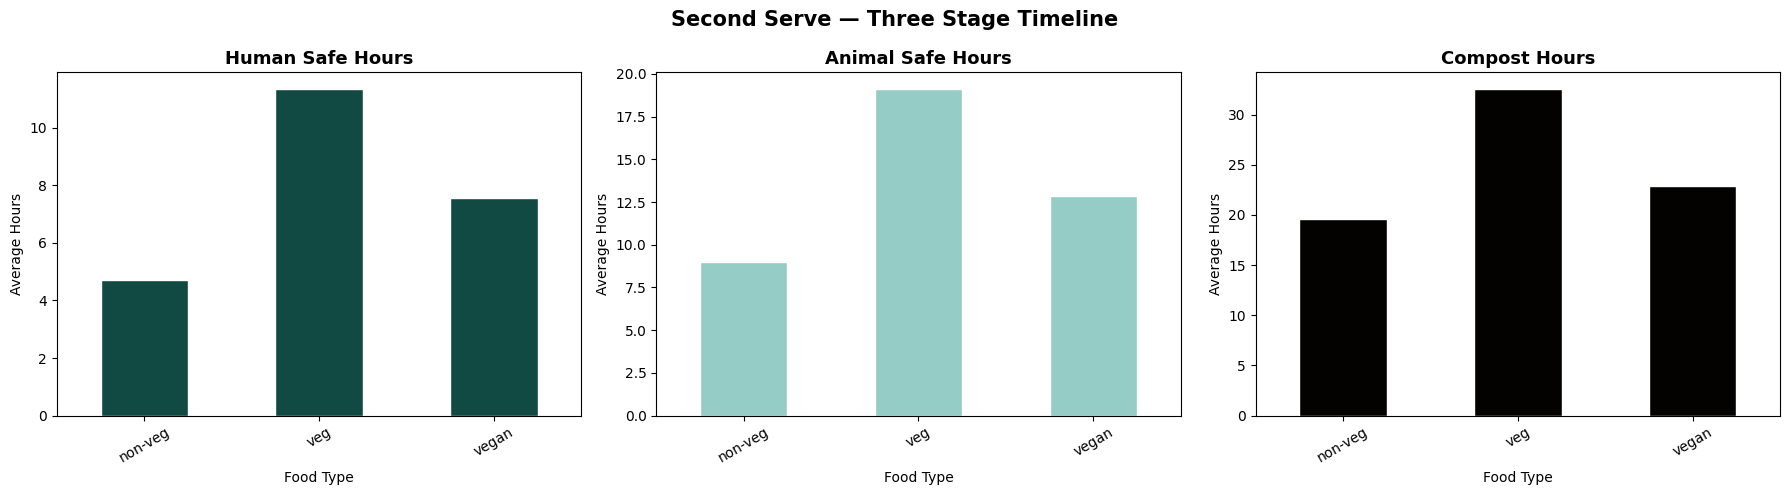

In [5]:
# Three stage timeline by food type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#114a42', '#95ccc5', '#030200']
cols   = ['human_safe_hours', 'animal_safe_hours', 'compost_hours']
titles = ['Human Safe Hours', 'Animal Safe Hours', 'Compost Hours']

for ax, col, color, title in zip(axes, cols, colors, titles):
    ref_df.groupby('food_type')[col].mean().plot(
        kind='bar', ax=ax, color=color, edgecolor='white'
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Food Type')
    ax.set_ylabel('Average Hours')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Second Serve — Three Stage Timeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/stage_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

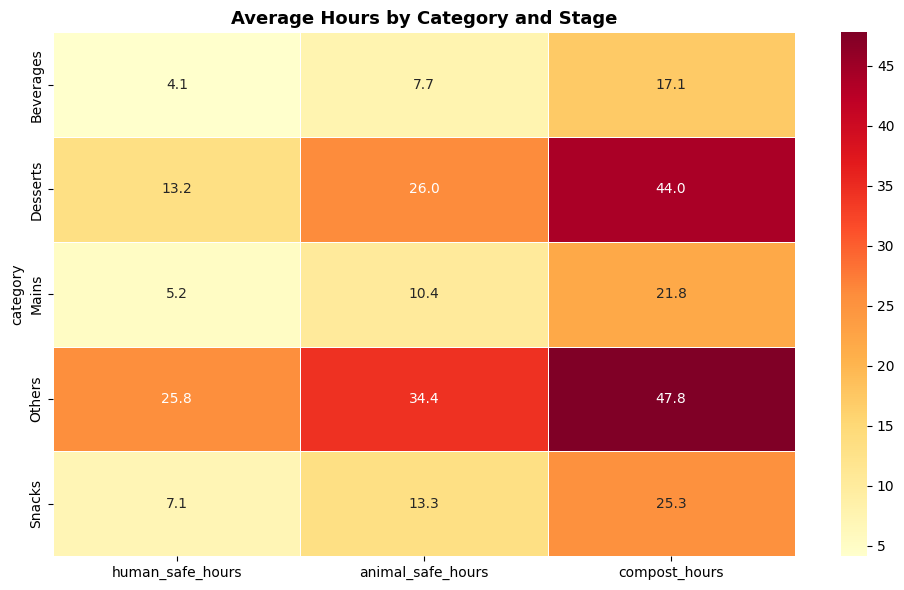

In [6]:
# Heatmap — category vs stage
pivot = ref_df.groupby('category')[['human_safe_hours','animal_safe_hours','compost_hours']].mean()
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Hours by Category and Stage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/stage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

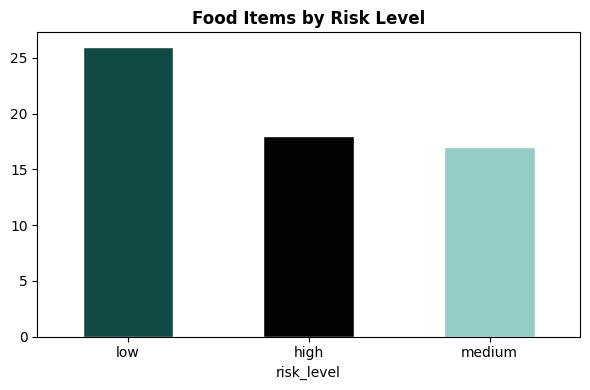

In [7]:
# Risk level distribution
risk_counts = ref_df['risk_level'].value_counts()
colors_risk = [{'low':'#114a42','medium':'#95ccc5','high':'#030200'}.get(r,'gray') for r in risk_counts.index]
risk_counts.plot(kind='bar', color=colors_risk, edgecolor='white', figsize=(6,4))
plt.title('Food Items by Risk Level', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/risk_distribution.png', dpi=150)
plt.show()

## 3. Generate Training Data

Simulates 50 samples per food item at different hours_since_prep values.

In [8]:
np.random.seed(42)
rows = []

for _, row in ref_df.iterrows():
    human_h   = row['human_safe_hours']
    animal_h  = row['animal_safe_hours']
    compost_h = row['compost_hours']
    max_h     = compost_h * 1.1

    for _ in range(50):
        hsp = round(np.random.uniform(0, max_h), 2)

        rem_human   = round(max(0, human_h   - hsp + np.random.normal(0, human_h * 0.03)), 2)
        rem_animal  = round(max(0, animal_h  - hsp + np.random.normal(0, animal_h * 0.03)), 2)
        rem_compost = round(max(0, compost_h - hsp), 2)

        if hsp <= human_h:
            stage = 'human'
        elif hsp <= animal_h:
            stage = 'animal'
        elif hsp <= compost_h:
            stage = 'compost'
        else:
            stage = 'waste'

        rows.append({
            'food_type':         row['food_type'],
            'category':          row['category'],
            'storage_temp':      row['storage_temp'],
            'risk_level':        row['risk_level'],
            'human_safe_hours':  human_h,
            'animal_safe_hours': animal_h,
            'compost_hours':     compost_h,
            'hours_since_prep':  hsp,
            'remaining_human_hours':   rem_human,
            'remaining_animal_hours':  rem_animal,
            'remaining_compost_hours': rem_compost,
            'redistribution_stage':    stage
        })

train_df = pd.DataFrame(rows)
print('Training data shape:', train_df.shape)
print('Stage distribution:')
print(train_df['redistribution_stage'].value_counts())
train_df.head()

Training data shape: (3050, 12)
Stage distribution:
redistribution_stage
compost    1389
human       753
animal      642
waste       266
Name: count, dtype: int64


,food_type,category,storage_temp,risk_level,human_safe_hours,animal_safe_hours,compost_hours,hours_since_prep,remaining_human_hours,remaining_animal_hours,remaining_compost_hours,redistribution_stage
0,veg,Mains,room_temp,medium,6,12,24,9.89,0.00,2.22,14.11,animal
1,veg,Mains,room_temp,medium,6,12,24,4.12,2.16,8.16,19.88,human
2,veg,Mains,room_temp,medium,6,12,24,0.54,5.36,11.27,23.46,human
3,veg,Mains,room_temp,medium,6,12,24,4.84,1.20,6.47,19.16,human
4,veg,Mains,room_temp,medium,6,12,24,11.40,0.00,0.05,12.60,animal


## 4. Encode Features

In [9]:
le_food_type = LabelEncoder()
le_category  = LabelEncoder()
le_storage   = LabelEncoder()
le_risk      = LabelEncoder()
le_stage     = LabelEncoder()

train_df['food_type_enc'] = le_food_type.fit_transform(train_df['food_type'])
train_df['category_enc']  = le_category.fit_transform(train_df['category'])
train_df['storage_enc']   = le_storage.fit_transform(train_df['storage_temp'])
train_df['risk_enc']      = le_risk.fit_transform(train_df['risk_level'])
train_df['stage_enc']     = le_stage.fit_transform(train_df['redistribution_stage'])

print('food_type classes:', le_food_type.classes_)
print('category classes:',  le_category.classes_)
print('risk classes:',      le_risk.classes_)
print('stage classes:',     le_stage.classes_)

food_type classes: ['non-veg' 'veg' 'vegan']
category classes: ['Beverages' 'Desserts' 'Mains' 'Others' 'Snacks']
risk classes: ['high' 'low' 'medium']
stage classes: ['animal' 'compost' 'human' 'waste']


## 5. Train Regression Models

In [10]:
FEATURES = [
    'food_type_enc', 'category_enc', 'storage_enc', 'risk_enc',
    'human_safe_hours', 'animal_safe_hours', 'compost_hours',
    'hours_since_prep'
]

X = train_df[FEATURES]
trained_models = {}

for target in ['remaining_human_hours', 'remaining_animal_hours', 'remaining_compost_hours']:
    y = train_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)

    print(f'{target:<35} MAE: {mae:.3f}  R2: {r2:.3f}')
    trained_models[target] = model

remaining_human_hours               MAE: 0.130  R2: 0.997
remaining_animal_hours              MAE: 0.290  R2: 0.997
remaining_compost_hours             MAE: 0.118  R2: 1.000


## 6. Train Stage Classifier

In [11]:
y_stage = train_df['stage_enc']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_stage, test_size=0.2, random_state=42
)

stage_model = GradientBoostingClassifier(n_estimators=150, random_state=42)
stage_model.fit(X_train_s, y_train_s)

stage_preds = stage_model.predict(X_test_s)
print(classification_report(y_test_s, stage_preds, target_names=le_stage.classes_))

              precision    recall  f1-score   support

      animal       0.96      0.98      0.97       121
     compost       0.98      1.00      0.99       251
       human       1.00      0.97      0.99       176
       waste       1.00      0.95      0.98        62

    accuracy                           0.98       610
   macro avg       0.98      0.97      0.98       610
weighted avg       0.98      0.98      0.98       610



## 7. Evaluation Plots

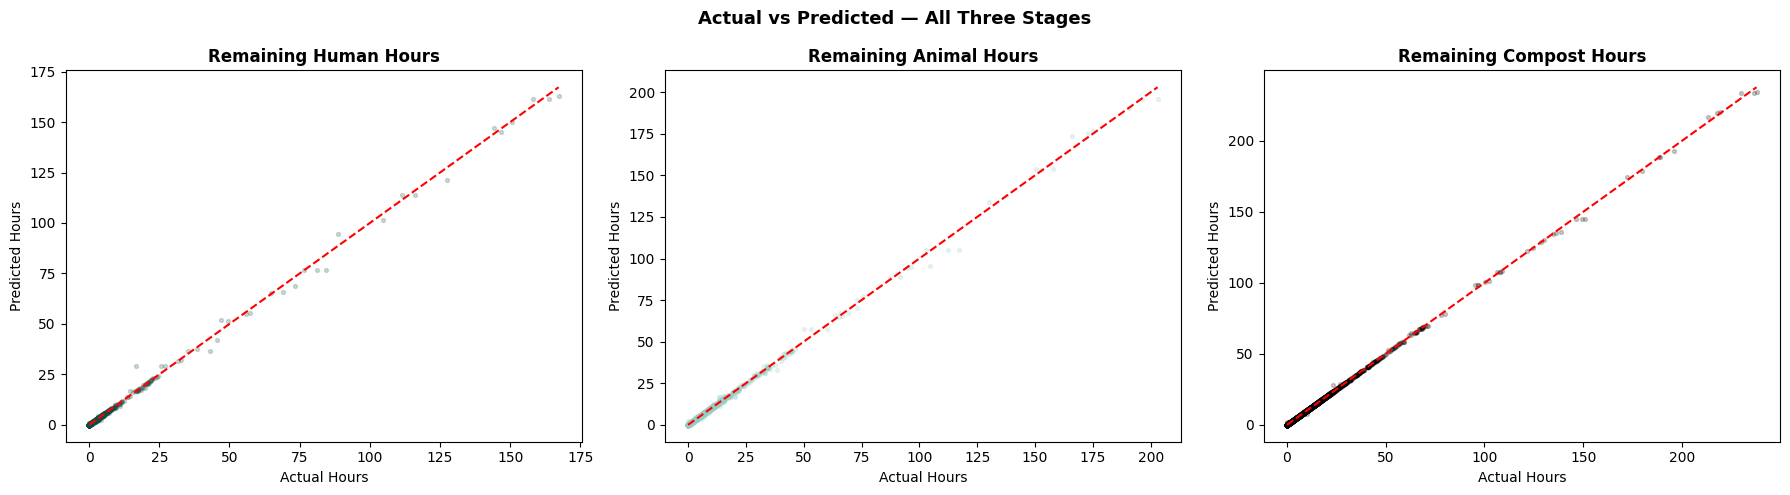

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#114a42', '#95ccc5', '#030200']

for ax, (target, model), color in zip(axes, trained_models.items(), colors):
    y_true = train_df[target]
    y_pred = model.predict(X)
    ax.scatter(y_true, y_pred, alpha=0.2, color=color, s=8)
    mv = float(y_true.max())
    ax.plot([0, mv], [0, mv], 'r--', lw=1.5)
    ax.set_title(target.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('Actual Hours')
    ax.set_ylabel('Predicted Hours')

plt.suptitle('Actual vs Predicted — All Three Stages', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

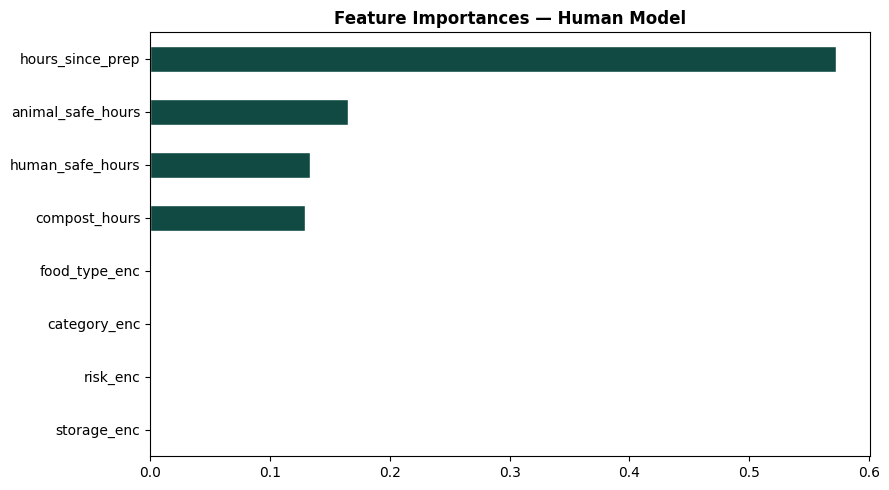

In [13]:
# Feature importances
importances = pd.Series(
    trained_models['remaining_human_hours'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(9,5), color='#114a42', edgecolor='white')
plt.title('Feature Importances — Human Model', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_importances.png', dpi=150)
plt.show()

## 8. Save All Models and Encoders

In [14]:
joblib.dump(trained_models['remaining_human_hours'],   'models/model_human.pkl')
joblib.dump(trained_models['remaining_animal_hours'],  'models/model_animal.pkl')
joblib.dump(trained_models['remaining_compost_hours'], 'models/model_compost.pkl')
joblib.dump(stage_model,  'models/model_stage.pkl')
joblib.dump(le_food_type, 'models/le_food_type.pkl')
joblib.dump(le_category,  'models/le_category.pkl')
joblib.dump(le_storage,   'models/le_storage.pkl')
joblib.dump(le_risk,      'models/le_risk.pkl')
joblib.dump(le_stage,     'models/le_stage.pkl')
ref_df.to_csv('models/food_reference.csv', index=False)

print('All models saved to ml_pipeline/models/')
print('Files:')
for f in sorted(os.listdir('models')):
    print(' ', f)

All models saved to ml_pipeline/models/
Files:
  demand_model.pkl
  food_reference.csv
  knn_receiver_tree.pkl
  le_area.pkl
  le_category.pkl
  le_demand.pkl
  le_food_demand.pkl
  le_food_type.pkl
  le_risk.pkl
  le_stage.pkl
  le_storage.pkl
  model_animal.pkl
  model_compost.pkl
  model_human.pkl
  model_stage.pkl
  receivers_reference.csv


## 9. Quick Prediction Test

In [15]:
food_ref = pd.read_csv('models/food_reference.csv')

def predict(food_name, hours_since_prep):
    match = food_ref[food_ref['food_type'].str.lower() == food_name.lower()]
    if match.empty:
        match = food_ref.iloc[[0]]
    row = match.iloc[0]

    feat = np.array([[
        le_food_type.transform([row['food_type']])[0],
        le_category.transform([row['category']])[0],
        le_storage.transform([row['storage_temp']])[0],
        le_risk.transform([row['risk_level']])[0],
        row['human_safe_hours'],
        row['animal_safe_hours'],
        row['compost_hours'],
        hours_since_prep
    ]])

    return {
        'food': food_name,
        'hours_since_prep': hours_since_prep,
        'remaining_human':   round(max(0, trained_models['remaining_human_hours'].predict(feat)[0]), 2),
        'remaining_animal':  round(max(0, trained_models['remaining_animal_hours'].predict(feat)[0]), 2),
        'remaining_compost': round(max(0, trained_models['remaining_compost_hours'].predict(feat)[0]), 2),
        'stage': le_stage.inverse_transform([stage_model.predict(feat)[0]])[0]
    }

# Tests
print(predict('Chicken Curry', 2))
print(predict('Chicken Curry', 5))
print(predict('Rice (cooked)', 3))
print(predict('Gulab Jamun', 10))
print(predict('Fish Curry', 6))

{'food': 'Chicken Curry', 'hours_since_prep': 2, 'remaining_human': np.float64(4.05), 'remaining_animal': np.float64(10.02), 'remaining_compost': np.float64(21.94), 'stage': 'human'}
{'food': 'Chicken Curry', 'hours_since_prep': 5, 'remaining_human': np.float64(1.06), 'remaining_animal': np.float64(7.09), 'remaining_compost': np.float64(18.99), 'stage': 'human'}
{'food': 'Rice (cooked)', 'hours_since_prep': 3, 'remaining_human': np.float64(2.97), 'remaining_animal': np.float64(8.94), 'remaining_compost': np.float64(21.01), 'stage': 'human'}
{'food': 'Gulab Jamun', 'hours_since_prep': 10, 'remaining_human': 0, 'remaining_animal': np.float64(1.86), 'remaining_compost': np.float64(14.05), 'stage': 'animal'}
{'food': 'Fish Curry', 'hours_since_prep': 6, 'remaining_human': np.float64(0.06), 'remaining_animal': np.float64(6.07), 'remaining_compost': np.float64(18.01), 'stage': 'animal'}
